In [1]:
import numpy as np


def compute_alpha_schedule(T=500, s=1e-5, clip_min=0.001):
    """
    Computes the recomputed alpha schedule based on the paper's methodology.
    Identical to the previous correct version.
    """
    t_vals = np.arange(0, T + 1)

    # Raw schedule f(t)
    f_t = 1 - (t_vals / T)**2
    alpha_raw = (1 - 2*s) * f_t + s

    # Recompute with stability clipping
    alpha_recomputed = np.zeros(T + 1)
    current_alpha = 1.0

    for t in range(0, T + 1):
        prev_raw = 1.0 if t == 0 else alpha_raw[t-1]
        curr_raw = alpha_raw[t]

        # Calculate ratio squared and clip
        ratio_sq = (curr_raw / prev_raw)**2
        ratio_sq_clipped = max(ratio_sq, clip_min)

        # Accumulate
        current_alpha = current_alpha * np.sqrt(ratio_sq_clipped)
        alpha_recomputed[t] = current_alpha

    return alpha_recomputed

def get_general_reverse_variance(t, s, alpha_schedule):
    """
    Computes the reverse process variance for the transition z_t -> z_s.
    
    Formula based on Image 2:
    sigma_{t->s} = (sigma_{t|s} * sigma_s) / sigma_t
    
    Args:
        t (int): Current time step.
        s (int): Next time step (target), must be < t.
        alpha_schedule (np.array): Precomputed alpha values.
        
    Returns:
        float: The variance sigma_{t->s}^2.
    """
    if s >= t:
        raise ValueError(f"Target step s ({s}) must be less than current step t ({t})")
    if t >= len(alpha_schedule):
        raise ValueError(f"Step t ({t}) is out of bounds for schedule of length {len(alpha_schedule)}")

    # 1. Retrieve Alphas
    alpha_t = alpha_schedule[t]
    alpha_s = alpha_schedule[s]

    # 2. Compute basic Sigmas (sigma^2 = 1 - alpha^2)
    # Note: The paper defines alpha_t approx 1 -> 0, so sigma adds noise.
    sigma_t_sq = 1 - alpha_t**2
    sigma_s_sq = 1 - alpha_s**2

    # Avoid division by zero if t is very small (though t>s>=0 implies t>=1)
    if sigma_t_sq < 1e-12:
        return 0.0

    # 3. Compute Transition Terms (Eq 2 details)
    # alpha_{t|s} = alpha_t / alpha_s
    alpha_t_given_s = alpha_t / alpha_s

    # sigma_{t|s}^2 = sigma_t^2 - alpha_{t|s}^2 * sigma_s^2
    sigma_t_given_s_sq = sigma_t_sq - (alpha_t_given_s**2 * sigma_s_sq)

    # Handle potential negative zero due to float precision
    sigma_t_given_s_sq = max(sigma_t_given_s_sq, 0.0)

    # 4. Compute Posterior Variance (Eq 4 details)
    # Variance = (sigma_{t|s}^2 * sigma_s^2) / sigma_t^2
    variance = (sigma_t_given_s_sq * sigma_s_sq) / sigma_t_sq

    return variance


In [2]:
def get_variance_list(alphas, T, interval):
    variances = []
    current_t = T
    while current_t > 0:
        target_s = max(current_t - interval, 0)
        var = get_general_reverse_variance(current_t, target_s, alphas)
        variances.append(var)
        current_t = target_s
    return variances


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt


def resample_array(values: np.ndarray, target_length: int) -> np.ndarray:
    if len(values) == target_length:
        return values
    else:
        x_original = np.linspace(0, 1, num=len(values))
        x_target = np.linspace(0, 1, num=target_length)
        return np.interp(x_target, x_original, values)

def plot_curve(values: np.ndarray, x_range: np.ndarray, x_label: str, y_label: str, output_path: Path = None) -> None:
    plt.figure(figsize=(8, 4.5))
    plt.plot(x_range, values, linewidth=2)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.tight_layout()
    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=200)
    # plt.close()

def plot_curves(
    curves: list[tuple[str, np.ndarray]], x_ranges: list[np.ndarray], x_label: str, y_label: str, log_scale: bool = False, output_path: Path = None
) -> None:
    if not curves:
        raise ValueError("No curves provided for plotting.")

    plt.figure(figsize=(8, 4.5))

    for (label, values), x_range in zip(curves, x_ranges):
        plt.plot(x_range, values, linewidth=2, label=label)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.gca().invert_xaxis() # Convention: process goes from T to 0
    plt.tight_layout()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    if log_scale:
        plt.yscale("log")
    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=200)
        # also save as svg
        plt.savefig(output_path.with_suffix('.svg'))
    plt.show()
    plt.close()

In [4]:

# --- Example Usage with Custom Interval ---

# 1. Generate Schedule
alphas = compute_alpha_schedule(T=500)

# 2. Compute variances for a "Strided" sampling process
# e.g., t = 500 -> 490 -> 480 ... -> 0 (Step size 10)
interval = 10
variances_list = []
steps_log = []

current_t = 500
while current_t > 0:
    target_s = max(current_t - interval, 0) # Ensure s doesn't go below 0

    var = get_general_reverse_variance(current_t, target_s, alphas)
    variances_list.append(var)
    steps_log.append(f"{current_t}->{target_s}")

    current_t = target_s

# Print first 10 steps of the strided variance
print("Computed Variances for Strided Sampling (first 5 steps):")
for step_desc, val in zip(steps_log[:5], variances_list[:5]):
    print(f"Step {step_desc}: {val:.6e}")

Computed Variances for Strided Sampling (first 5 steps):
Step 500->490: 9.984209e-01
Step 490->480: 7.413923e-01
Step 480->470: 5.422375e-01
Step 470->460: 4.213617e-01
Step 460->450: 3.420014e-01


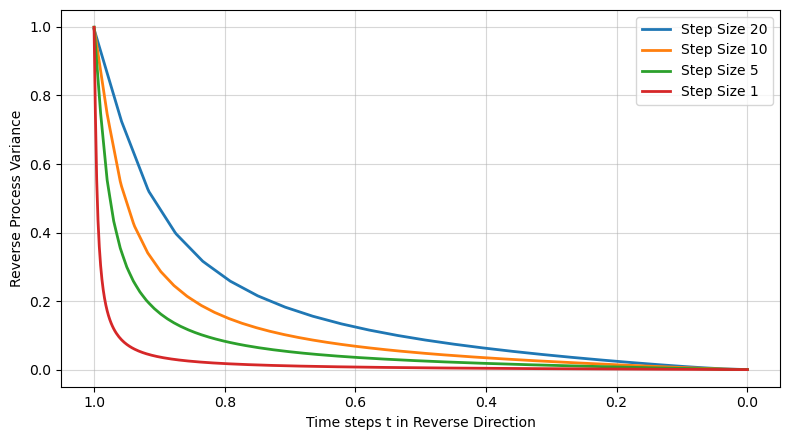

In [5]:
T = 500
alphas = compute_alpha_schedule(T=T)

variances_list_interval_20 = get_variance_list(alphas, T=T, interval=20)
variances_list_interval_10 = get_variance_list(alphas, T=T, interval=10)
variances_list_interval_5 = get_variance_list(alphas, T=T, interval=5)
variances_list_interval_1 = get_variance_list(alphas, T=T, interval=1)

# convert to numpy arrays
array_i20 = np.array(variances_list_interval_20)
array_i10 = np.array(variances_list_interval_10)
array_i5 = np.array(variances_list_interval_5)
array_i1 = np.array(variances_list_interval_1)


# [Version 1] Plot all curves together for comparison, with resampling to common length
plot_curves(
    curves=[
        ("Step Size 20", resample_array(array_i20, T)),
        ("Step Size 10", resample_array(array_i10, T)),
        ("Step Size 5", resample_array(array_i5, T)),
        ("Step Size 1", resample_array(array_i1, T)),
    ],
    x_ranges=[
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
    ],
    x_label="Time steps t in Reverse Direction",
    y_label="Reverse Process Variance",
    output_path=Path("reverse_variance_comparison.png"),
)

# [Version 2] Plot all curves together for comparison
# plot_curves(
#     curves=[
#         ("Interval 20", array_i20),
#         ("Interval 10", array_i10),
#         ("Interval 5", array_i5),
#         ("Interval 1", array_i1),
#     ],
#     x_ranges=[
#         np.linspace(1, 0, num=len(array_i20)),
#         np.linspace(1, 0, num=len(array_i10)),
#         np.linspace(1, 0, num=len(array_i5)),
#         np.linspace(1, 0, num=len(array_i1)),
#     ],
#     x_label="Time steps t in reverse direction",
#     y_label="Reverse Process Variance",
#     output_path=Path("reverse_variance_comparison.png"),
# )



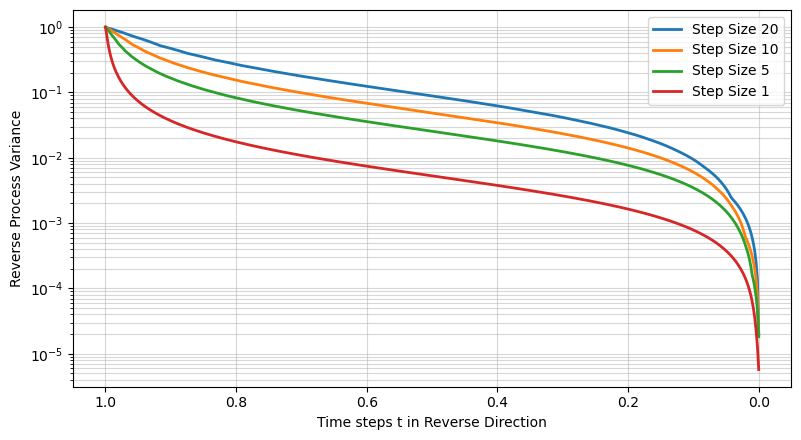

In [17]:
T = 500
alphas = compute_alpha_schedule(T=T)

variances_list_interval_20 = get_variance_list(alphas, T=T, interval=20)
variances_list_interval_10 = get_variance_list(alphas, T=T, interval=10)
variances_list_interval_5 = get_variance_list(alphas, T=T, interval=5)
variances_list_interval_1 = get_variance_list(alphas, T=T, interval=1)

# convert to numpy arrays
array_i20 = np.array(variances_list_interval_20)
array_i10 = np.array(variances_list_interval_10)
array_i5 = np.array(variances_list_interval_5)
array_i1 = np.array(variances_list_interval_1)

# [Version 1] Plot all curves together for comparison, using resampling
plot_curves(
    curves=[
        ("Step Size 20", resample_array(array_i20, T)),
        ("Step Size 10", resample_array(array_i10, T)),
        ("Step Size 5", resample_array(array_i5, T)),
        ("Step Size 1", resample_array(array_i1, T)),
    ],
    x_ranges=[
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
        np.linspace(1, 0, num=T),
    ],
    x_label="Time steps t in Reverse Direction",
    y_label="Reverse Process Variance",
    log_scale=True,
    output_path=Path("reverse_variance_comparison_logscale.png"),
)

# [Version 2] Plot all curves together for comparison
# plot_curves(
#     curves=[
#         ("Interval 20", array_i20),
#         ("Interval 10", array_i10),
#         ("Interval 5", array_i5),
#         ("Interval 1", array_i1),
#     ],
#     x_ranges=[
#         np.linspace(1, 0, num=len(array_i20)),
#         np.linspace(1, 0, num=len(array_i10)),
#         np.linspace(1, 0, num=len(array_i5)),
#         np.linspace(1, 0, num=len(array_i1)),
#     ],
#     x_label="Time steps t in reverse direction",
#     y_label="Reverse Process Variance",
#     log_scale=True,
#     output_path=Path("reverse_variance_comparison_logscale.png"),
# )

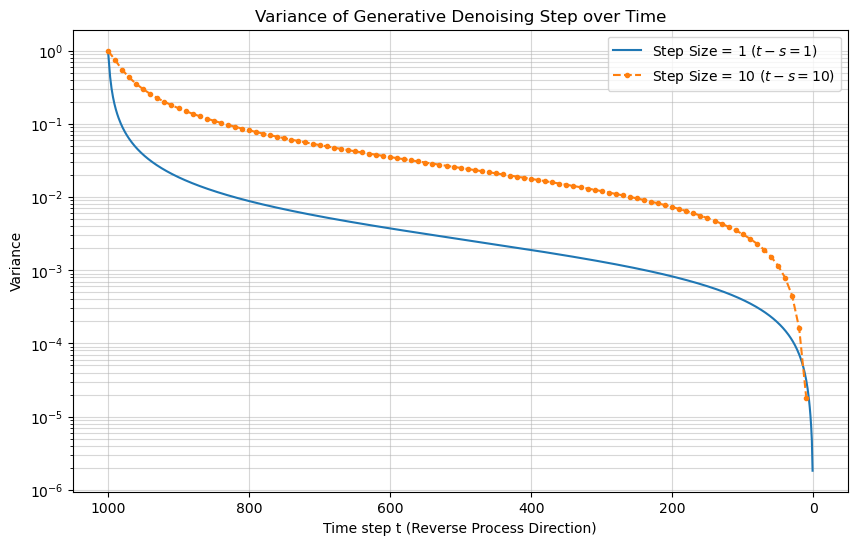

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def get_alpha_t(t, T=1000, s_prec=1e-5):
    # alpha_t = (1 - 2s) * f(t) + s
    # f(t) = 1 - (t/T)^2
    ft = 1 - (t / T)**2
    return (1 - 2 * s_prec) * ft + s_prec

def get_variance_t_to_s(t, step_size, T=1000, s_prec=1e-5):
    s = t - step_size

    alpha_t = get_alpha_t(t, T, s_prec)
    alpha_s = get_alpha_t(s, T, s_prec)

    sigma_t_sq = 1 - alpha_t**2
    sigma_s_sq = 1 - alpha_s**2

    # Avoid division by zero at t=0, but loop starts at t>=1
    if sigma_t_sq == 0:
        return 0

    alpha_ratio_sq = (alpha_t / alpha_s)**2
    sigma_t_given_s_sq = sigma_t_sq - alpha_ratio_sq * sigma_s_sq

    # Clip small negative values due to precision
    if sigma_t_given_s_sq < 0:
        sigma_t_given_s_sq = 0

    # sigma_{t->s}^2 = sigma_{t|s}^2 * sigma_s^2 / sigma_t^2
    variance = (sigma_t_given_s_sq * sigma_s_sq) / sigma_t_sq
    return variance

# Step size 1
t_range_1 = np.arange(1000, 1, -1) # t goes from 1000 down to 2. s goes 999 to 1.
# Actually let's go down to 1 so s goes to 0? The paper uses s=0 as data.
t_range_1 = np.arange(1000, 0, -1)
variances_1 = [get_variance_t_to_s(t, 1) for t in t_range_1]

# Step size 10
# t goes from 1000, 990, ..., 10. s goes 990, ..., 0.
t_range_10 = np.arange(1000, 9, -10)
variances_10 = [get_variance_t_to_s(t, 10) for t in t_range_10]

plt.figure(figsize=(10, 6))
plt.plot(t_range_1, variances_1, label='Step Size = 1 ($t-s=1$)')
plt.plot(t_range_10, variances_10, label='Step Size = 10 ($t-s=10$)', marker='.', linestyle='--')

plt.xlabel('Time step t (Reverse Process Direction)')
plt.ylabel('Variance')
plt.title('Variance of Generative Denoising Step over Time')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.yscale('log') # Log scale to see the behavior across orders of magnitude
plt.gca().invert_xaxis() # Convention: process goes from T to 0
# plt.savefig('variance_comparison_log.png')
plt.show()

# # Linear scale version for comparison/clarity on the high values
# plt.figure(figsize=(10, 6))
# plt.plot(t_range_1, variances_1, label='Step Size = 1 ($t-s=1$)')
# plt.plot(t_range_10, variances_10, label='Step Size = 10 ($t-s=10$)', marker='.', linestyle='--')
# plt.xlabel('Time step t (Reverse Process Direction)')
# plt.ylabel('Variance')
# plt.title('Variance of Generative Denoising Step over Time (Linear Scale)')
# plt.legend()
# plt.grid(True, which="both", ls="-", alpha=0.5)
# plt.gca().invert_xaxis()
# plt.savefig('variance_comparison_linear.png')

## Compare Allaround Performance

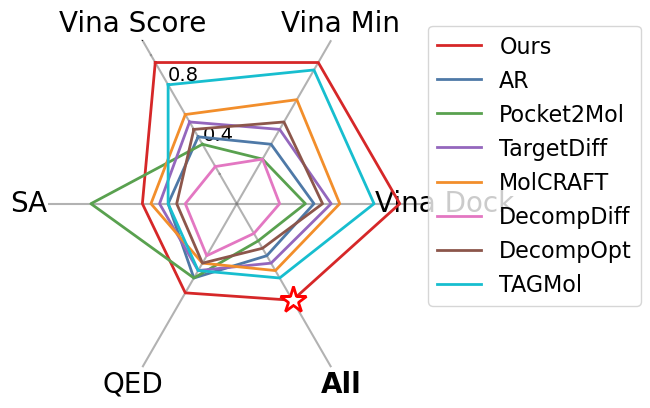

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. DATA PREPARATION
categories = ['Vina Score', 'Vina Min', 'Vina Dock', 'All', 'QED', 'SA']
N = len(categories)

data = {
    'Ours':       [0.95, 0.95, 0.95, 0.65, 0.60, 0.55],
    'AR':         [0.45, 0.40, 0.45, 0.35, 0.50, 0.40],
    'Pocket2Mol': [0.40, 0.30, 0.40, 0.25, 0.50, 0.85],
    'TargetDiff': [0.55, 0.50, 0.55, 0.40, 0.45, 0.45],
    'MolCRAFT':   [0.60, 0.70, 0.60, 0.45, 0.40, 0.50],
    'DecompDiff': [0.25, 0.30, 0.25, 0.20, 0.35, 0.30],
    'DecompOpt':  [0.50, 0.55, 0.50, 0.30, 0.40, 0.35],
    'TAGMol':     [0.80, 0.90, 0.80, 0.50, 0.45, 0.40],
}

colors = {
    'Ours':       '#d62728', 
    'AR':         '#4e79a7',
    'Pocket2Mol': '#59a14f',
    'TargetDiff': '#9467bd',
    'MolCRAFT':   '#f28e2b',
    'DecompDiff': '#e377c2',
    'DecompOpt':  '#8c564b',
    'TAGMol':     '#17becf',
}

# 2. SETUP PLOT
# Create angles
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Initialize Polar Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

# Rotation: Vina Score at top-left
ax.set_theta_offset(np.pi / 1.5) 
ax.set_theta_direction(-1)

# 3. PLOT DATA LINES
for label, values in data.items():
    values_copy = values + values[:1]
    ax.plot(angles, values_copy, linewidth=2, label=label, color=colors[label])

# Star Marker on "All" for "Ours"
all_idx = 3
ax.plot(angles[all_idx], data['Ours'][all_idx], marker='*', markersize=20, 
        color='white', markeredgecolor='red', markeredgewidth=2, zorder=10)

# 4. GRID & AXES CONFIGURATION (The Fix)

# Force the grid to be on, dark gray, and solid
ax.grid(True, color='gray', linestyle='-', linewidth=1.5, alpha=0.6)

# Configure the radial (circle) grid lines
ax.set_rlabel_position(0)
yticks = [0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(yticks)
# Only label 0.4 and 0.8
ax.set_yticklabels(["" if y not in [0.4, 0.8] else str(y) for y in yticks], 
                   color="black", size=14)

# force radial (circular) gridlines
ax.yaxis.grid(True, color="gray", linestyle="-", linewidth=1.5, alpha=0.6)
# optional: keep spokes too
ax.xaxis.grid(True, color="gray", linestyle="-", linewidth=1.5, alpha=0.6)

ax.set_rgrids(yticks, labels=["", "0.4", "", "0.8", ""], angle=0)

# Set the limit to ensure the outer circle (1.0) is visible but not cut off
ax.set_ylim(0, 1.1)

# Configure the spokes (category lines)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=20)

# Bold the "All" label
labels = ax.get_xticklabels()
for label in labels:
    if label.get_text() == 'All':
        label.set_fontweight('bold')

# Ensure the outer circle spine is visible
ax.spines['polar'].set_visible(True)
ax.spines['polar'].set_color('black')

# 5. LEGEND
plt.legend(loc='upper right', bbox_to_anchor=(1.6, 1.0), fontsize=16)

plt.tight_layout()
plt.show()

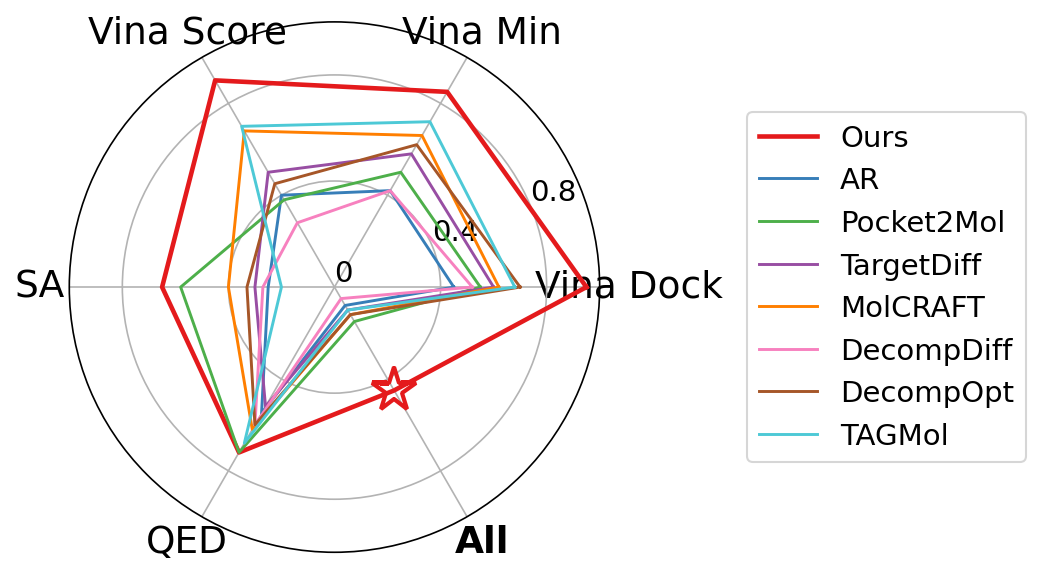

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --- Data (0–1 normalized). Replace with your exact values. ---
categories = ["Vina Dock", "Vina Min", "Vina Score", "SA", "QED", "All"]

data = {
    "Ours":       [0.95, 0.85, 0.90, 0.65, 0.72, 0.45],
    "AR":         [0.45, 0.42, 0.40, 0.25, 0.55, 0.08],
    "Pocket2Mol": [0.55, 0.50, 0.38, 0.58, 0.72, 0.15],
    "TargetDiff": [0.60, 0.58, 0.50, 0.30, 0.52, 0.10],
    "MolCRAFT":   [0.62, 0.66, 0.68, 0.40, 0.62, 0.12],
    "DecompDiff": [0.52, 0.42, 0.28, 0.27, 0.60, 0.05],
    "DecompOpt":  [0.70, 0.62, 0.45, 0.33, 0.60, 0.12],
    "TAGMol":     [0.68, 0.72, 0.70, 0.20, 0.68, 0.10],
}

colors = {
    "Ours": "#e41a1c",       # red
    "AR": "#377eb8",         # blue
    "Pocket2Mol": "#4daf4a", # green
    "TargetDiff": "#984ea3", # purple
    "MolCRAFT": "#ff7f00",   # orange
    "DecompDiff": "#f781bf", # pink
    "DecompOpt": "#a65628",  # brown
    "TAGMol": "#4dc9d6",     # cyan
}

# --- Radar setup ---
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
angles_closed = np.r_[angles, angles[0]]

fig = plt.figure(figsize=(12, 4), dpi=150)
ax = plt.subplot(111, polar=True)

# Match layout: start at the right, go counterclockwise
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)

# Grid / limits / ticks
ax.set_ylim(0, 1.0)
ax.set_yticks([0.0, 0.4, 0.8])
ax.set_yticklabels(["0", "0.4", "0.8"], fontsize=14)
ax.yaxis.grid(True, color="0.7", lw=0.8)
ax.xaxis.grid(True, color="0.7", lw=0.8)

# Category labels (big like the reference)
ax.set_xticks(angles)
xt = ax.set_xticklabels(categories, fontsize=18)
# Make "All" bold
xt[-1].set_fontweight("bold")

# --- Plot lines ---
for name, vals in data.items():
    vals = np.asarray(vals, dtype=float)
    vals_closed = np.r_[vals, vals[0]]
    lw = 2.2 if name == "Ours" else 1.4
    ax.plot(angles_closed, vals_closed, color=colors[name], lw=lw, label=name)

# Red star marker on "All" axis (as in the image)
all_idx = categories.index("All")
ax.plot([angles[all_idx]], [data["Ours"][all_idx]],
        marker="*", markersize=22, markerfacecolor="none",
        markeredgewidth=2.0, markeredgecolor=colors["Ours"], zorder=5)

# Legend on the right
ax.legend(loc="center left", bbox_to_anchor=(1.25, 0.5),
          frameon=True, fontsize=14)

# --- Add green check box near the "All" label (approximate placement) ---
# Place in axes coordinates so it stays in the same spot visually
# box = Rectangle((0.79, 0.08), 0.06, 0.10, transform=ax.transAxes,
#                 facecolor="#12a300", edgecolor="black", lw=1.5, zorder=10)
# ax.add_patch(box)
# ax.text(0.82, 0.10, "✓", transform=ax.transAxes, fontsize=20,
#         color="white", fontweight="bold", zorder=11)

plt.tight_layout()
plt.show()


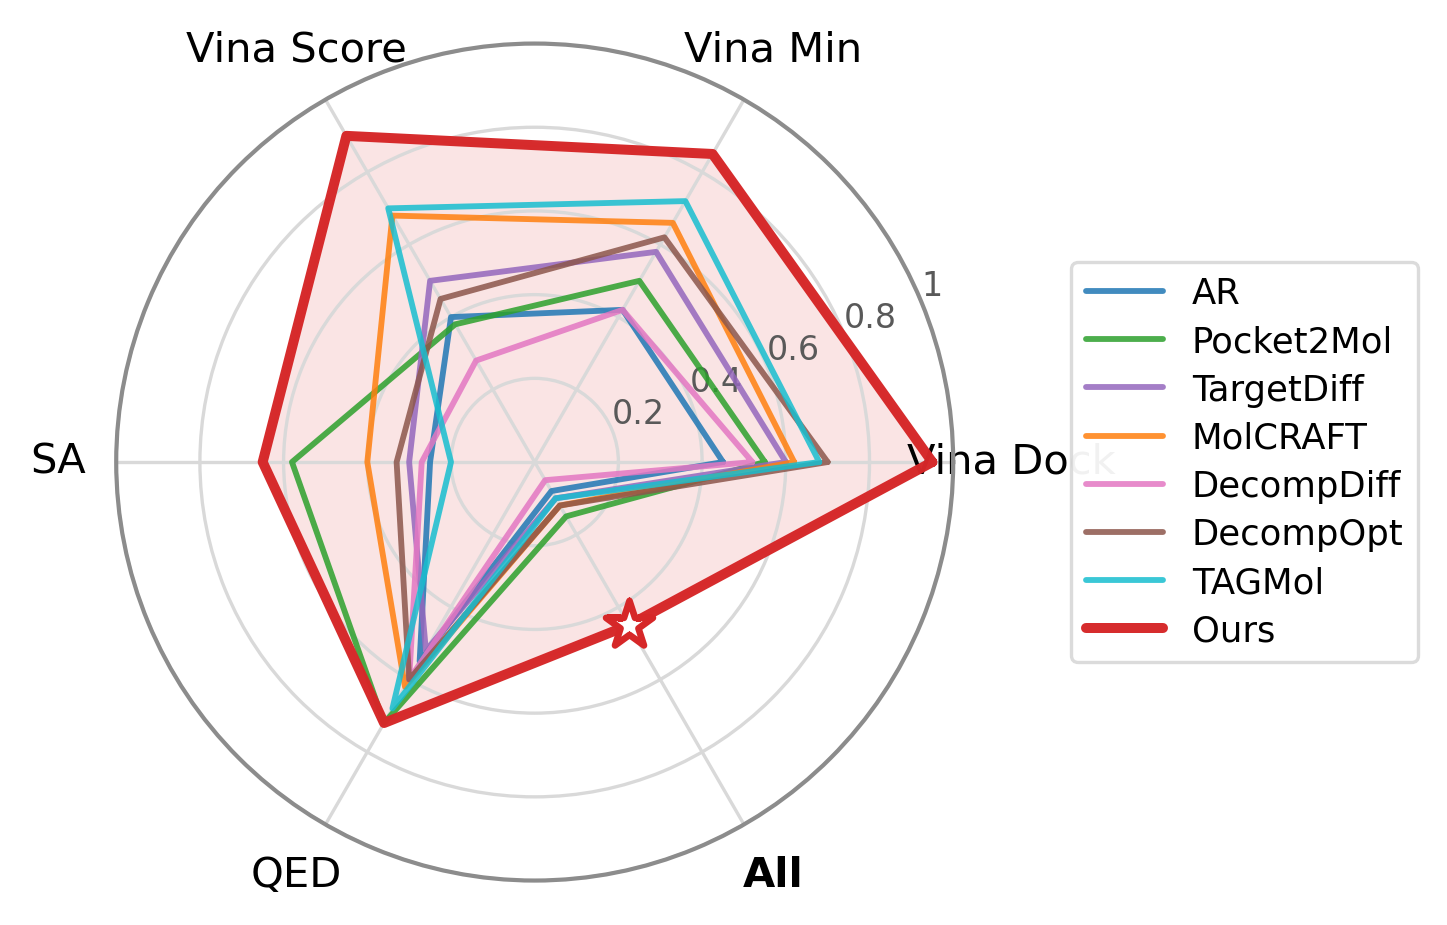

In [11]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

def radar_paper_plot(
    categories,
    series_dict,
    colors=None,
    highlight="Ours",
    star_axis="All",
    star_series="Ours",
    rmax=1.0,
    rticks=(0.2, 0.4, 0.6, 0.8, 1.0),
    figsize=(7.2, 3.2),
    outpath=None,   # e.g. "radar.pdf" or "radar.svg"
):
    """
    Paper-friendly radar chart (clean grid, consistent typography, export-ready).
    series_dict: {name: [values...]} values should be in [0, 1] or normalized.
    """

    # --- Global style (safe defaults for papers) ---
    mpl.rcParams.update({
        "font.family": "DejaVu Sans",      # change to "Times New Roman" if your venue requires
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 10,
        "legend.fontsize": 8.5,
        "pdf.fonttype": 42,  # embed TrueType fonts
        "ps.fonttype": 42,
    })

    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)
    angles_closed = np.r_[angles, angles[0]]

    fig = plt.figure(figsize=figsize, dpi=300)
    ax = fig.add_subplot(111, polar=True)

    # Put first axis at the right, go CCW (matches your reference)
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)

    # Limits and ticks
    ax.set_ylim(0, rmax)
    ax.set_yticks(rticks)
    ax.set_yticklabels([f"{t:g}" for t in rticks], color="0.35")
    ax.tick_params(axis="y", labelsize=8)

    ax.set_xticks(angles)
    xlabels = ax.set_xticklabels(categories)
    for t in xlabels:
        t.set_fontsize(10)
    # Optionally bold the last label (e.g., "All")
    if "All" in categories:
        xlabels[categories.index("All")].set_fontweight("bold")

    # Subtle grid and spine (paper-friendly)
    ax.grid(True, color="0.85", lw=0.8)
    ax.spines["polar"].set_color("0.55")
    ax.spines["polar"].set_linewidth(1.0)

    # Default color cycle if none supplied
    if colors is None:
        base = plt.rcParams["axes.prop_cycle"].by_key()["color"]
        names = list(series_dict.keys())
        colors = {n: base[i % len(base)] for i, n in enumerate(names)}
        if highlight in colors:
            colors[highlight] = "#d62728"  # nice red highlight

    # Plot order: put highlight last so it sits on top
    names = list(series_dict.keys())
    if highlight in names:
        names = [n for n in names if n != highlight] + [highlight]

    # Draw series
    handles = []
    for name in names:
        vals = np.asarray(series_dict[name], dtype=float)
        vals_closed = np.r_[vals, vals[0]]

        is_hi = (name == highlight)
        lw = 2.4 if is_hi else 1.4
        alpha_line = 0.98 if is_hi else 0.85

        line, = ax.plot(
            angles_closed, vals_closed,
            color=colors.get(name, None),
            lw=lw,
            alpha=alpha_line,
            solid_capstyle="round",
            solid_joinstyle="round",
            label=name,
            zorder=3 if is_hi else 2
        )
        handles.append(line)

        # Light fill for highlight only (keeps plot readable)
        if is_hi:
            ax.fill(angles_closed, vals_closed, color=line.get_color(), alpha=0.12, zorder=1)

    # Add star marker at a chosen axis for a chosen series
    if (star_axis in categories) and (star_series in series_dict):
        idx = categories.index(star_axis)
        r = float(series_dict[star_series][idx])
        ax.scatter(
            [angles[idx]], [r],
            marker="*", s=140,
            facecolors="white",
            edgecolors=colors.get(star_series, "k"),
            linewidths=1.6,
            zorder=5
        )

    # Legend: compact, outside, no heavy frame
    leg = ax.legend(
        loc="center left",
        bbox_to_anchor=(1.12, 0.5),
        frameon=True,
        borderpad=0.4,
        handlelength=2.2,
        labelspacing=0.4
    )
    leg.get_frame().set_edgecolor("0.85")
    leg.get_frame().set_linewidth(0.8)
    leg.get_frame().set_alpha(0.95)

    fig.tight_layout()

    if outpath:
        fig.savefig(outpath, bbox_inches="tight")
        print(f"Saved: {outpath}")

    return fig, ax


# ----------------- Example usage (replace values with yours) -----------------
categories = ["Vina Dock", "Vina Min", "Vina Score", "SA", "QED", "All"]

series = {
    "Ours":       [0.95, 0.85, 0.90, 0.65, 0.72, 0.45],
    "AR":         [0.45, 0.42, 0.40, 0.25, 0.55, 0.08],
    "Pocket2Mol": [0.55, 0.50, 0.38, 0.58, 0.72, 0.15],
    "TargetDiff": [0.60, 0.58, 0.50, 0.30, 0.52, 0.10],
    "MolCRAFT":   [0.62, 0.66, 0.68, 0.40, 0.62, 0.12],
    "DecompDiff": [0.52, 0.42, 0.28, 0.27, 0.60, 0.05],
    "DecompOpt":  [0.70, 0.62, 0.45, 0.33, 0.60, 0.12],
    "TAGMol":     [0.68, 0.72, 0.70, 0.20, 0.68, 0.10],
}

# Optional curated colors (colorblind-friendly-ish + consistent highlight)
colors = {
    "Ours": "#d62728",
    "AR": "#1f77b4",
    "Pocket2Mol": "#2ca02c",
    "TargetDiff": "#9467bd",
    "MolCRAFT": "#ff7f0e",
    "DecompDiff": "#e377c2",
    "DecompOpt": "#8c564b",
    "TAGMol": "#17becf",
}

radar_paper_plot(
    categories,
    series,
    colors=colors,
    highlight="Ours",
    star_axis="All",
    star_series="Ours",
    figsize=(7.6, 3.2),
    outpath=None,   # set to "radar.pdf" or "radar.svg" for submission
)

plt.show()
